In [6]:
from pathlib import Path 
import matplotlib.pyplot as plt 
import torch
from PIL import Image
from torchvision import transforms
from utils.model import VggEncoder

In [22]:
ROOT = Path.cwd()
EXAMPLES = ROOT / "examples"
VGG_WEIGHTS = ROOT / "vgg_normalised.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_size = 512

image_paths = {
    "Original Brad Pitt": EXAMPLES / "i_p_image.jpg",
    "Stylized Brad Pitt A": EXAMPLES / "stylized_i_p_image.jpg", 
    "Stylized Flight image": EXAMPLES / "stylized_000000000016.jpg"
}

transform = transforms.Compose([
    transforms.Resize( (image_size, image_size)),
    transforms.ToTensor(),
])

encoder = VggEncoder(str(VGG_WEIGHTS)).to(device).eval()

print("Using device:", device)

Using device: cuda


In [26]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    return image, tensor


def show_images (paths_dict):
    fig, axes = plt.subplots(1, len (paths_dict), figsize=(16, 5))
    for ax, (title, path) in zip (axes, paths_dict.items()):
        image = Image.open(path).convert("RGB")
        ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()


def extract_features (tensor):
    with torch.no_grad():
        h1, h2, h3, h4  = encoder (tensor)
        return {
            "relul_1": h1,
            "relu2_1": h2,
            "relu3_1": h3,
            "relu4_1": h4,
        }


def activation_map (feature_tensor):
    activation = feature_tensor[0].mean(dim=0).detach().cpu()
    activation = activation - activation.min()
    activation = activation / (activation.max() + 1e-8)
    return activation

In [30]:
image_tensors = {} 
feature_bank = {}

for name, path in image_paths.items():
    _, tensor = load_image(path)
    image_tensors[name] = tensor
    feature_bank[name] = extract_features(tensor)

for name, features in feature_bank.items():
    shapes = {layer: tuple(feature.shape) for layer, feature in features.items()}
    print (name)
    print(shapes)
    print()
    

Original Brad Pitt
{'relul_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}

Stylized Brad Pitt A
{'relul_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}

Stylized Flight image
{'relul_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}



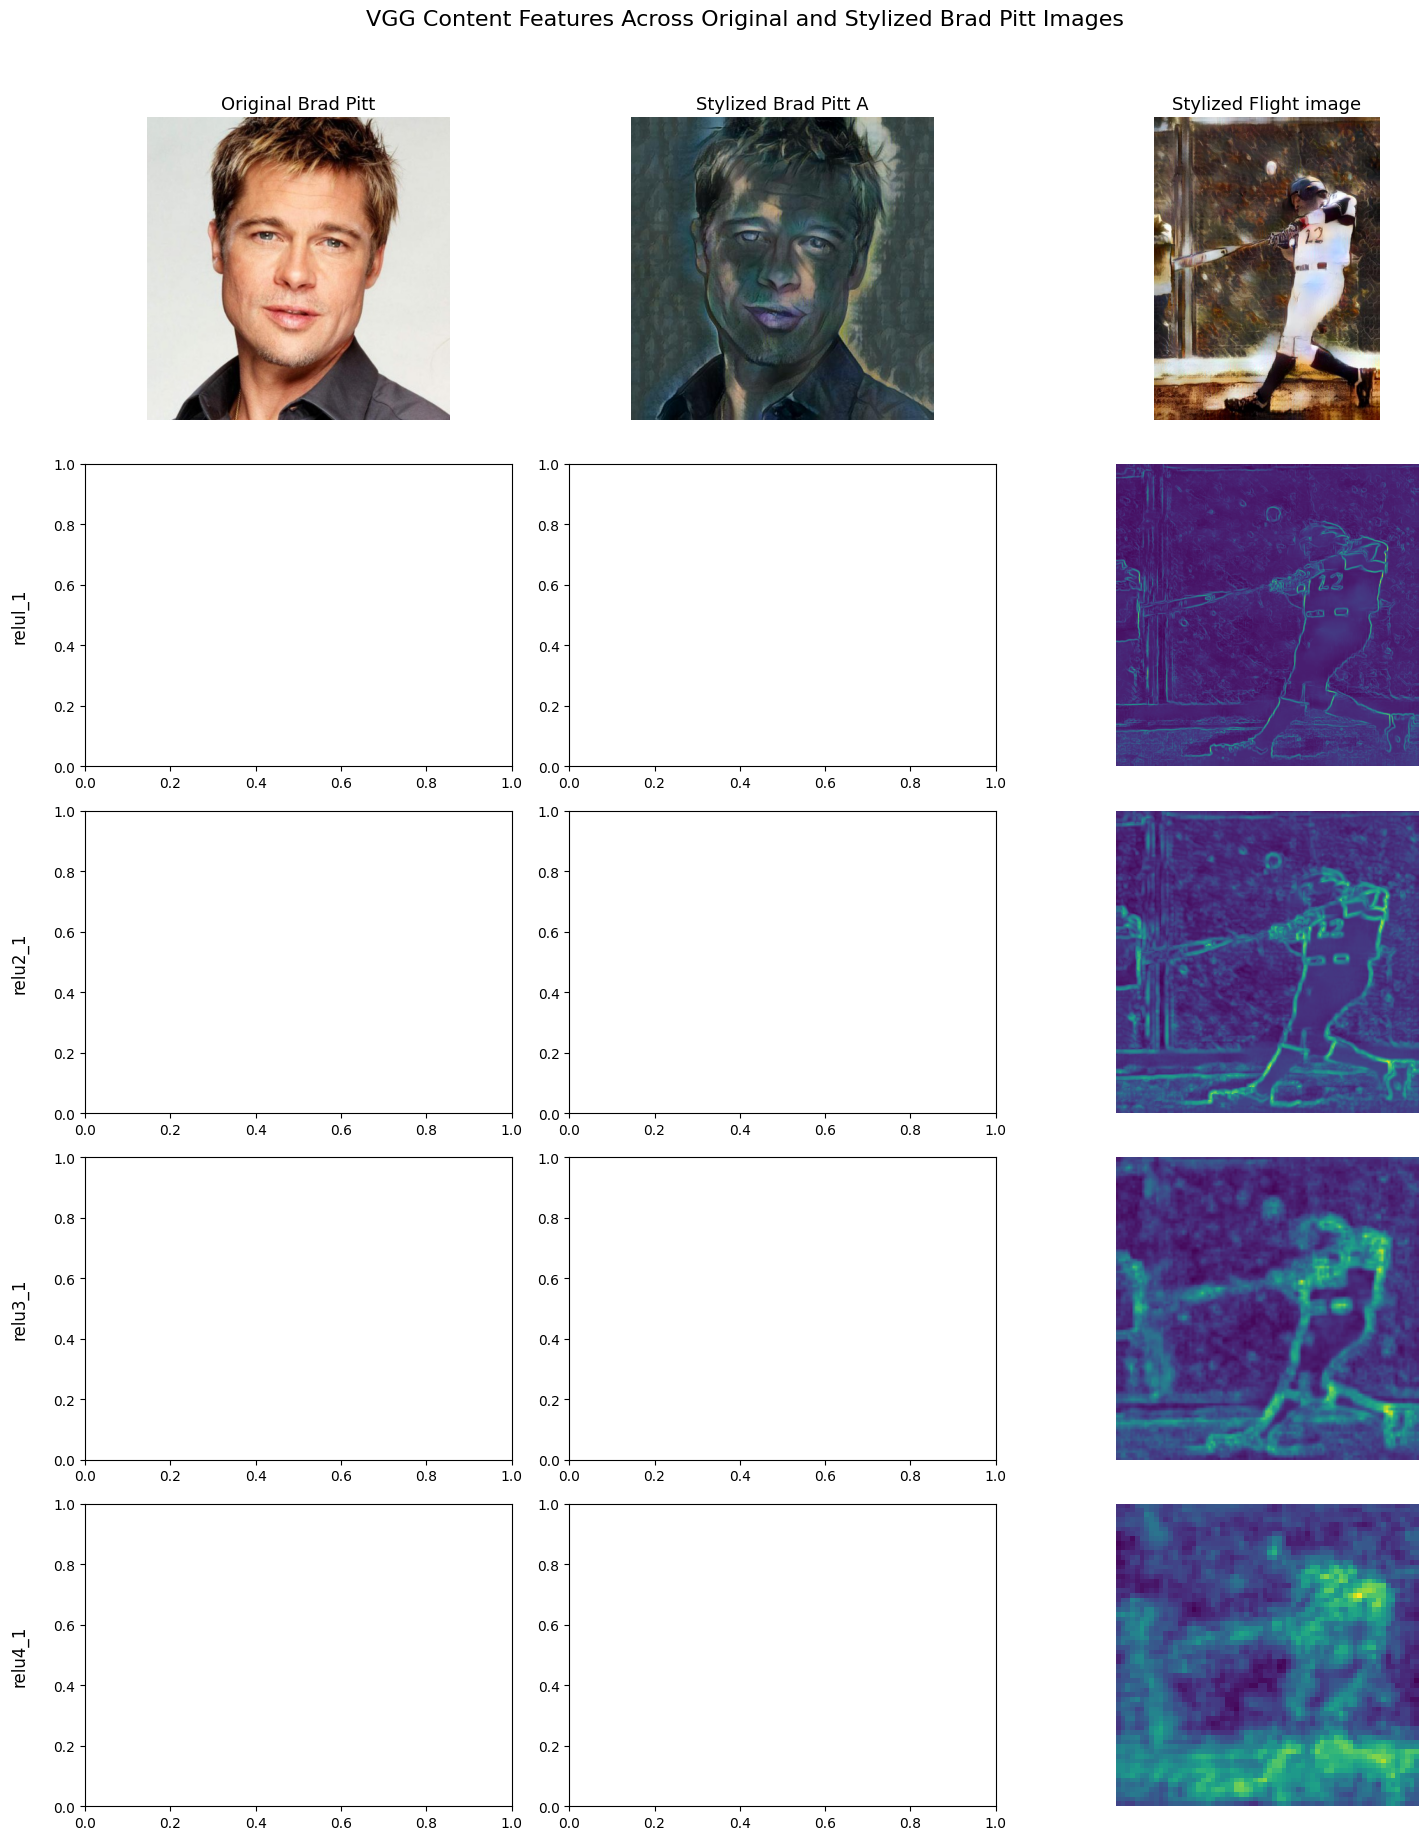

In [28]:
layers_to_show = ["relul_1", "relu2_1", "relu3_1", "relu4_1"]
row_labels = ["Input Image"] + layers_to_show
num_rows = len(row_labels)
num_cols = len(image_paths)

fig, axes = plt.subplots (num_rows, num_cols, figsize=(5* num_cols, 3.6 * num_rows))

for col, (name, path) in enumerate(image_paths.items()):
    image = Image.open (path).convert("RGB")
    axes[0, col].imshow(image)
    axes[0, col].set_title(name, fontsize=13)
    axes [0, col].axis("off")

for row, layer in enumerate (layers_to_show, start=1):
    axes[row, col].imshow(activation_map(feature_bank[name][layer]))
    axes[row, col].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=12, rotation=90, labelpad=18)
    
plt.suptitle("VGG Content Features Across Original and Stylized Brad Pitt Images", fontsize=16, y=1.02)
plt.tight_layout()